1. KÍCH THƯỚC VÀ MẪU DỮ LIỆU:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



2. THÔNG TIN CẤU TRÚC VÀ KIỂU DỮ LIỆU (DATA DICTIONARY):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

3. KIỂM TRA MISSING VÀ DUPLICATE:
- Số l

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


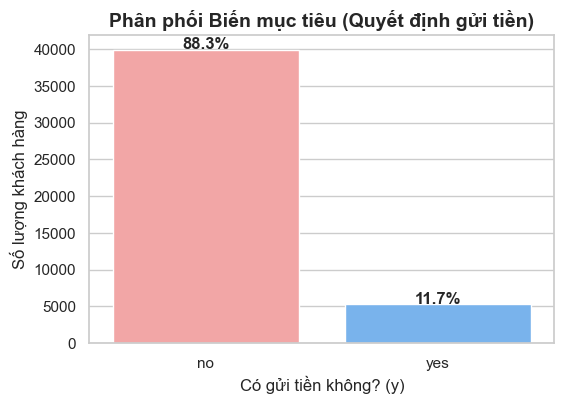

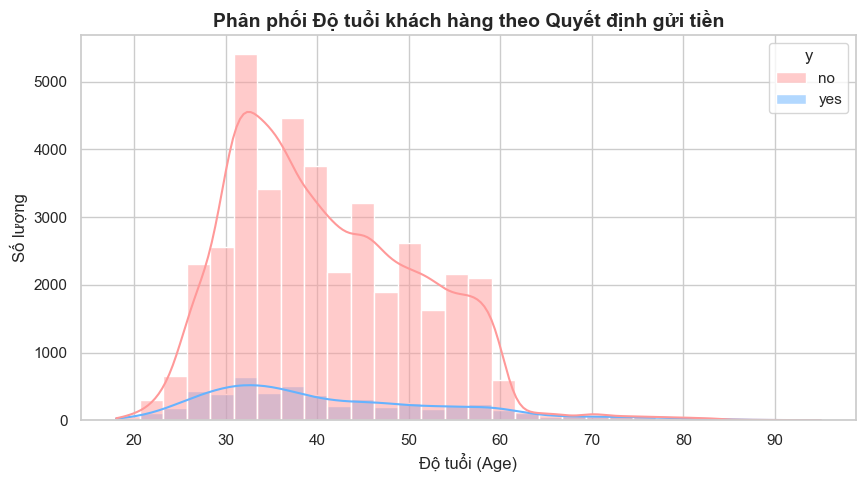

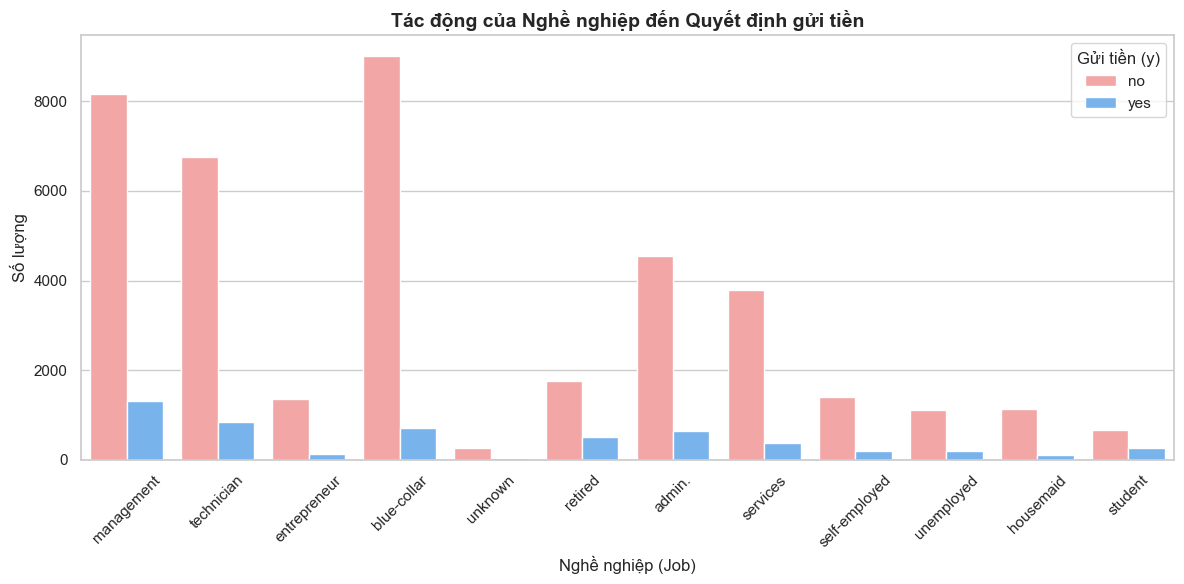

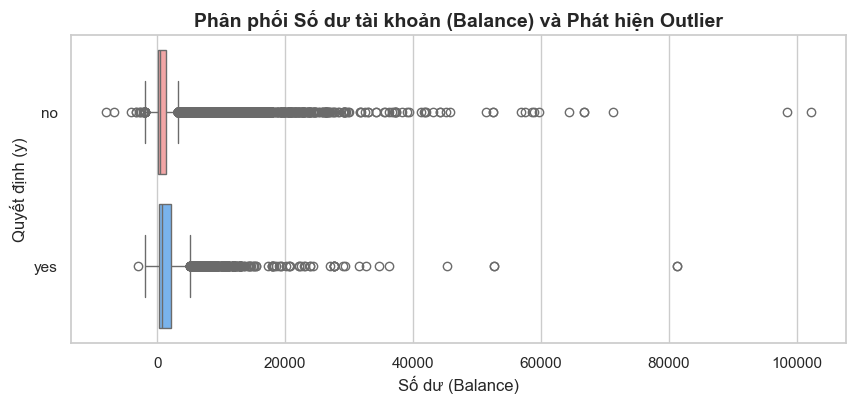

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Tắt các cảnh báo đỏ 
warnings.filterwarnings('ignore')

# Thiết lập style chung cho tất cả các biểu đồ 
sns.set_theme(style="whitegrid", palette="muted")

# ==========================================
# 1. TẢI VÀ KIỂM TRA DỮ LIỆU TỔNG QUAN
# ==========================================
print("1. KÍCH THƯỚC VÀ MẪU DỮ LIỆU:")
data = pd.read_csv("../data/raw/bank.csv", sep=";")
display(data.head())

print("\n2. THÔNG TIN CẤU TRÚC VÀ KIỂU DỮ LIỆU (DATA DICTIONARY):")
data.info()

print("\n3. KIỂM TRA MISSING VÀ DUPLICATE:")
print(f"- Số lượng dòng trùng lặp (Duplicates): {data.duplicated().sum()}")
# Kiểm tra giá trị 'unknown' đặc thù của bộ Bank
unknown_counts = (data == 'unknown').sum()
print("- Số lượng giá trị 'unknown' (Missing ngầm) trong từng cột:")
print(unknown_counts[unknown_counts > 0])

print("\n4. THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ HỌC:")
display(data.describe())

# ==========================================
# 2. TRỰC QUAN HÓA DỮ LIỆU (EDA)
# ==========================================

# BIỂU ĐỒ 1: KIỂM TRA MẤT CÂN BẰNG LỚP (BẮT BUỘC CHO TIÊU CHÍ A)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x='y', palette=['#ff9999', '#66b3ff'])
plt.title('Phân phối Biến mục tiêu (Quyết định gửi tiền)', fontsize=14, fontweight='bold')
plt.xlabel('Có gửi tiền không? (y)')
plt.ylabel('Số lượng khách hàng')

# Thêm % trực tiếp lên cột để dễ đọc
total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_y() + p.get_height() + 100
    ax.annotate(percentage, (x, y), fontweight='bold')
plt.show()


# BIỂU ĐỒ 2: PHÂN TÍCH PHÂN PHỐI ĐỘ TUỔI THEO QUYẾT ĐỊNH
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='age', hue='y', kde=True, bins=30, palette=['#ff9999', '#66b3ff'])
plt.title('Phân phối Độ tuổi khách hàng theo Quyết định gửi tiền', fontsize=14, fontweight='bold')
plt.xlabel('Độ tuổi (Age)')
plt.ylabel('Số lượng')
plt.show()


# BIỂU ĐỒ 3: PHÂN TÍCH NHÓM NGHỀ NGHIỆP CÓ TỶ LỆ GỬI TIỀN CAO NHẤT
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='job', hue='y', palette=['#ff9999', '#66b3ff'])
plt.title('Tác động của Nghề nghiệp đến Quyết định gửi tiền', fontsize=14, fontweight='bold')
plt.xlabel('Nghề nghiệp (Job)')
plt.ylabel('Số lượng')
plt.xticks(rotation=45) # Xoay nhãn trục X để không bị đè chữ
plt.legend(title='Gửi tiền (y)', loc='upper right')
plt.tight_layout()
plt.show()

# BIỂU ĐỒ 4 (BỔ SUNG CỘNG ĐIỂM): OUTLIER TRONG SỐ DƯ TÀI KHOẢN
plt.figure(figsize=(10, 4))
sns.boxplot(data=data, x='balance', y='y', orient='h', palette=['#ff9999', '#66b3ff'])
plt.title('Phân phối Số dư tài khoản (Balance) và Phát hiện Outlier', fontsize=14, fontweight='bold')
plt.xlabel('Số dư (Balance)')
plt.ylabel('Quyết định (y)')
plt.show()

<h1>Phân bố khách hàng đăng ký</h1>

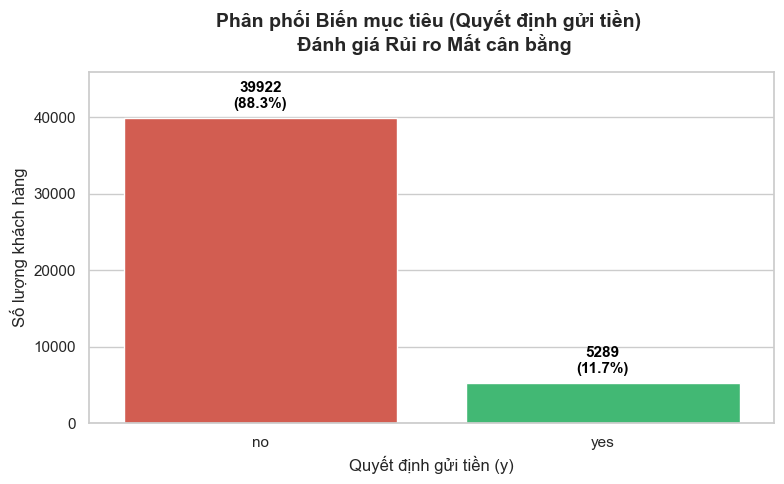

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thiết lập kích thước và style
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# 2. Vẽ biểu đồ với màu sắc tương phản (Đỏ/Xanh)
# Lưu ý: Thay 'yes'/'no' bằng 1/0 ở phần xticks nếu bạn đã encode biến y trước đó
ax = sns.countplot(x="y", data=data, palette=["#e74c3c", "#2ecc71"])

# 3. Tùy chỉnh tiêu đề và nhãn trục chuyên nghiệp
plt.title("Phân phối Biến mục tiêu (Quyết định gửi tiền) \n Đánh giá Rủi ro Mất cân bằng", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Quyết định gửi tiền (y)", fontsize=12)
plt.ylabel("Số lượng khách hàng", fontsize=12)

# 4. Thuật toán tự động tính và hiển thị % lên đỉnh từng cột
total = len(data)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    
    # In ra định dạng: Số lượng \n (Phần trăm)
    ax.annotate(f'{count}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='black', 
                xytext=(0, 5), textcoords='offset points')

# Mở rộng giới hạn trục Y thêm 15% để số liệu không bị lẹm vào viền trên
plt.ylim(0, data['y'].value_counts().max() * 1.15)
plt.tight_layout()
plt.show()

<h1>Phân tích theo nghề</h1>

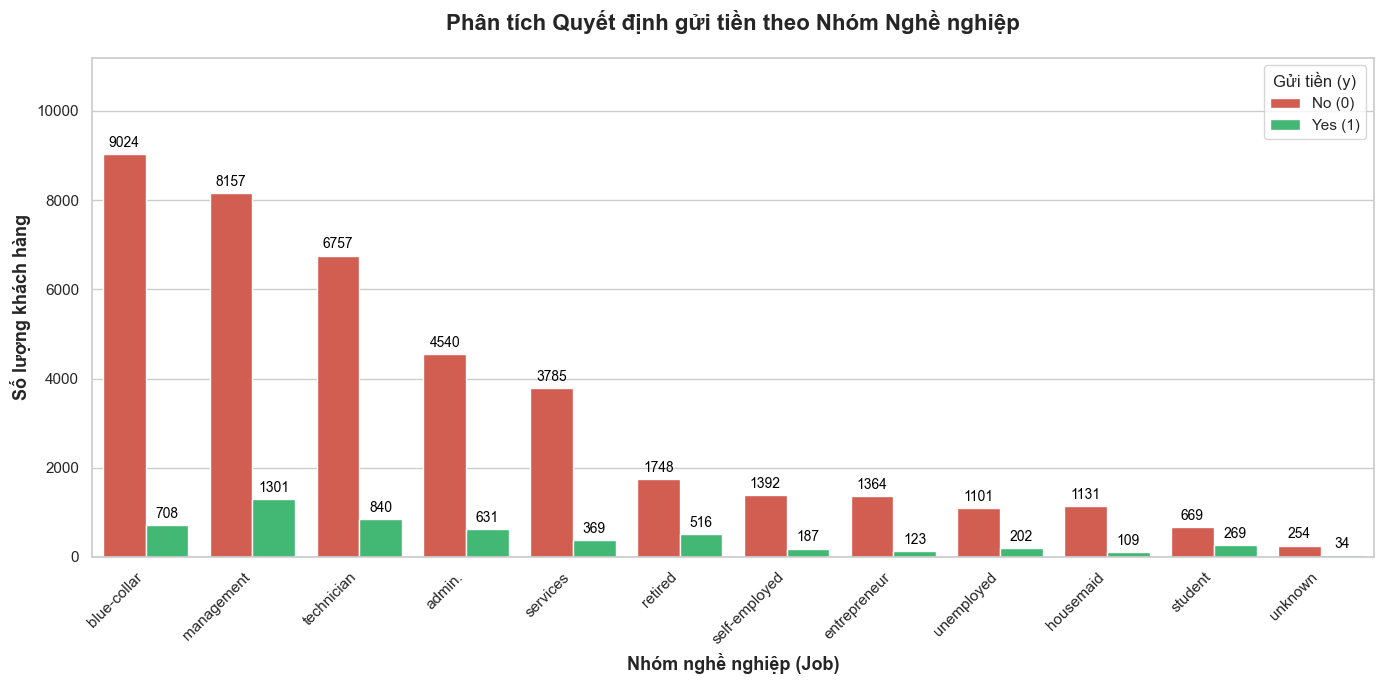

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Thiết lập kích thước lớn hơn một chút cho thoáng và style chuẩn
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 2. Sắp xếp các nghề nghiệp theo TỔNG SỐ LƯỢNG giảm dần để biểu đồ có tính phân tích
order_jobs = data['job'].value_counts().index

# 3. Vẽ biểu đồ với palette màu tương phản
ax = sns.countplot(x="job", hue="y", data=data, 
                   order=order_jobs, 
                   palette=["#e74c3c", "#2ecc71"]) # Đỏ cho 'no', Xanh cho 'yes'

# 4. Tùy chỉnh tiêu đề và nhãn trục chuyên nghiệp
plt.title("Phân tích Quyết định gửi tiền theo Nhóm Nghề nghiệp", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Nhóm nghề nghiệp (Job)", fontsize=13, fontweight='bold')
plt.ylabel("Số lượng khách hàng", fontsize=13, fontweight='bold')

# 5. Xoay nhãn trục X 45 độ và căn lề phải (ha='right') để chữ không bị đè lên nhau
plt.xticks(rotation=45, ha='right', fontsize=11)

# 6. Tự động gắn số lượng trực tiếp lên đỉnh các cột
for p in ax.patches:
    height = p.get_height()
    # Bỏ qua các cột bằng 0 để tránh lỗi hiển thị
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', 
                    xytext=(0, 3), textcoords='offset points')

# Mở rộng trục Y để nhãn số không bị cắt xén
plt.ylim(0, data['job'].value_counts().max() * 1.15)
plt.legend(title='Gửi tiền (y)', loc='upper right', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

<h1>Correlation Heatmap</h1>

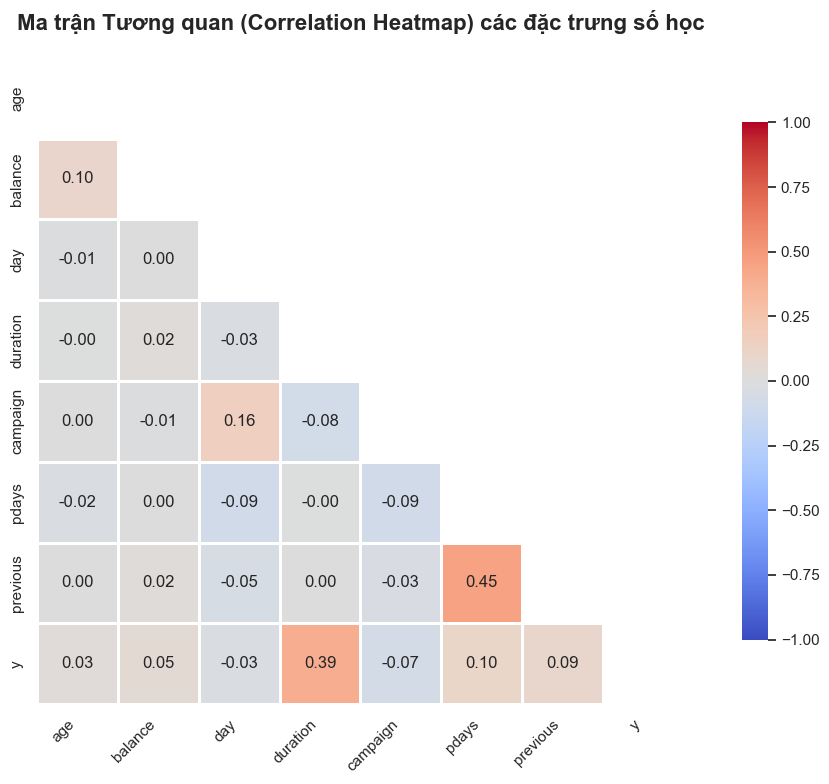

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Tạo bản sao và tạm thời mã hóa biến mục tiêu 'y' thành số (1/0) để xem mức độ tương quan
df_corr = data.copy()
if 'y' in df_corr.columns and df_corr['y'].dtype == 'object':
    df_corr['y'] = df_corr['y'].map({'yes': 1, 'no': 0})

# 2. Xử lý lỗi ValueError: Chỉ lọc lấy các cột có kiểu dữ liệu là số (int, float)
numeric_data = df_corr.select_dtypes(include=[np.number])

# 3. Tính toán ma trận tương quan Pearson
corr_matrix = numeric_data.corr()

# 4. Thiết lập kích thước đồ thị lớn và rõ nét
plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

# 5. Thủ thuật chuyên nghiệp: Tạo mask để che nửa trên của ma trận (vì nó đối xứng)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 6. Vẽ Heatmap với các thông số tối ưu
sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap="coolwarm", 
            vmax=1.0, vmin=-1.0, # Cố định thang đo từ -1 đến 1
            center=0,
            annot=True,          # Hiển thị số liệu trực tiếp trên ô
            fmt=".2f",           # Định dạng làm tròn 2 chữ số thập phân
            square=True,         # Đưa các ô về dạng hình vuông
            linewidths=1,        # Tạo đường viền trắng giữa các ô
            cbar_kws={"shrink": .8}) # Thu nhỏ thanh màu bên cạnh cho cân đối

# 7. Chỉnh sửa tiêu đề và nhãn
plt.title("Ma trận Tương quan (Correlation Heatmap) các đặc trưng số học", 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()